# Limitations with non-RNN architectures:

* Ignores sequence information
* Requires fixed sequence (input) length
* Learned parameters not shared across the sequance

# Problems with backprop in RNN

* Overly sensitive to recent inputs
* Low sensitivity to distant inputs
* Risk of vanishing and exploding gradients
* RNNs are great when important characteristics are a few time-steps back (like an AR model in signal processing)

# Organizing Inputs into RNNs

* Input Size - Number of feature dimenstions (e.g. number of data channels). Often set to 1.
* Sequence Length - Length of data snippet used for learning
* Batch size - Number of sequences to input per epoch
* Hidden size - Number of units in the hidden layer
* Number of layers - Number of hidden layers stacked on each other

# Libs

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# RNN type

In [ ]:
input_size  = 9  # number of features to extract
hidden_size = 16 # width of recurrent neural net (moving nn) where input is [t_0:t_i] and output is t_i
num_layers  = 1  # depth of recurrent neuran net (moving nn)
nonlinearity = 'tanh' # activation function
bias = True           # do we use biases in our neural net, if False all biases are 0

# create an RNN instance
rnn = nn.RNN(
    input_size,
    hidden_size,
    num_layers,
    nonlinearity,
    bias
)

print(rnn)

RNN(9, 16)


In [ ]:
??nn.RNN

# Intuition

* seq_length - this is the length, so how many consecutive t's are processed sequentially by the hidden state before backpropagation
* batch_size - this is the count of such seq_length streams processed in parallel

if our seq_length = 5 and batch_size = 2 that means:

```
BATCH 1
stream A: t0  → t1  → t2  → t3  → t4    => h_A(4)
stream B: t5  → t6  → t7  → t8  → t9    => h_B(9)

            |
            |  (hidden carried over)
            v

BATCH 2
stream A: t10 → t11 → t12 → t13 → t14   starts from h_A(4)   => h_A(14)
stream B: t15 → t16 → t17 → t18 → t19   starts from h_B(9)   => h_B(19)

            |
            |  (hidden carried over)
            v

BATCH 3
stream A: t20 → t21 → t22 → t23 → t24   starts from h_A(14)  => h_A(24)
stream B: t25 → t26 → t27 → t28 → t29   starts from h_B(19)  => h_B(29)

            |
            |  (hidden carried over)
            v

BATCH 4
stream A: t30 → t31 → t32 → t33 → t34   starts from h_A(24)  => h_A(34)
stream B: t35 → t36 → t37 → t38 → t39   starts from h_B(29)  => h_B(39)

            |
            |  (hidden carried over)
            v

BATCH 5
stream A: t40 → t41 → t42 → t43 → t44   starts from h_A(34)  => h_A(44)
stream B: t45 → t46 → t47 → t48 → t49   starts from h_B(39)  => h_B(49)
```


hidden carried over means that the previous hidden state of a given stream is used as the initial hidden state for the next batch of the same stream.
For example, $h_A(14)$ is computed starting from $h_A(4)$ and sequentially processing inputs $x_{10}, x_{11}, x_{12}, x_{13}, x_{14}$.

As we can see, each batch advances the global time by $(\text{batch_size} - 1)\cdot \text{seq_length}$, while the other streams compute the skipped segments in parallel.

Now, how we actually get predictions.
If we have 10 batches we receive 10 predictions.

So, if in batch 1 we have:

$$t_0, t_1, t_2, t_3, t_4$$

then these are summarized in $h_4$, and together with $x_5$ we compute

$$h_5 = f(x_5, h_4)$$

from which we receive $\text{pred } t_5$.

After that we calculate the loss for a given stream and a given batch:

$$L(\text{pred } t_5,\ \text{true } t_5)$$

We do exactly the same thing for each stream in the batch, and eventually we average the losses:

$$L = \frac{1}{B}\sum_{i=1}^{B} L_i$$

and compute the gradient

$$\nabla W = \frac{\partial L}{\partial W}$$

So, we update the weights $W$ using the partial derivative of the averaged losses with respect to the weights.

We need to remember that the weights $W$ are shared across all streams and all hidden states.
Common weights ensure that even though we process multiple interleaved temporal streams that advance by $(\text{batch_size} - 1)\cdot \text{seq_length}$, we still optimize a single model of the underlying sequence dynamics.

Below is 1 timestep of LSTM

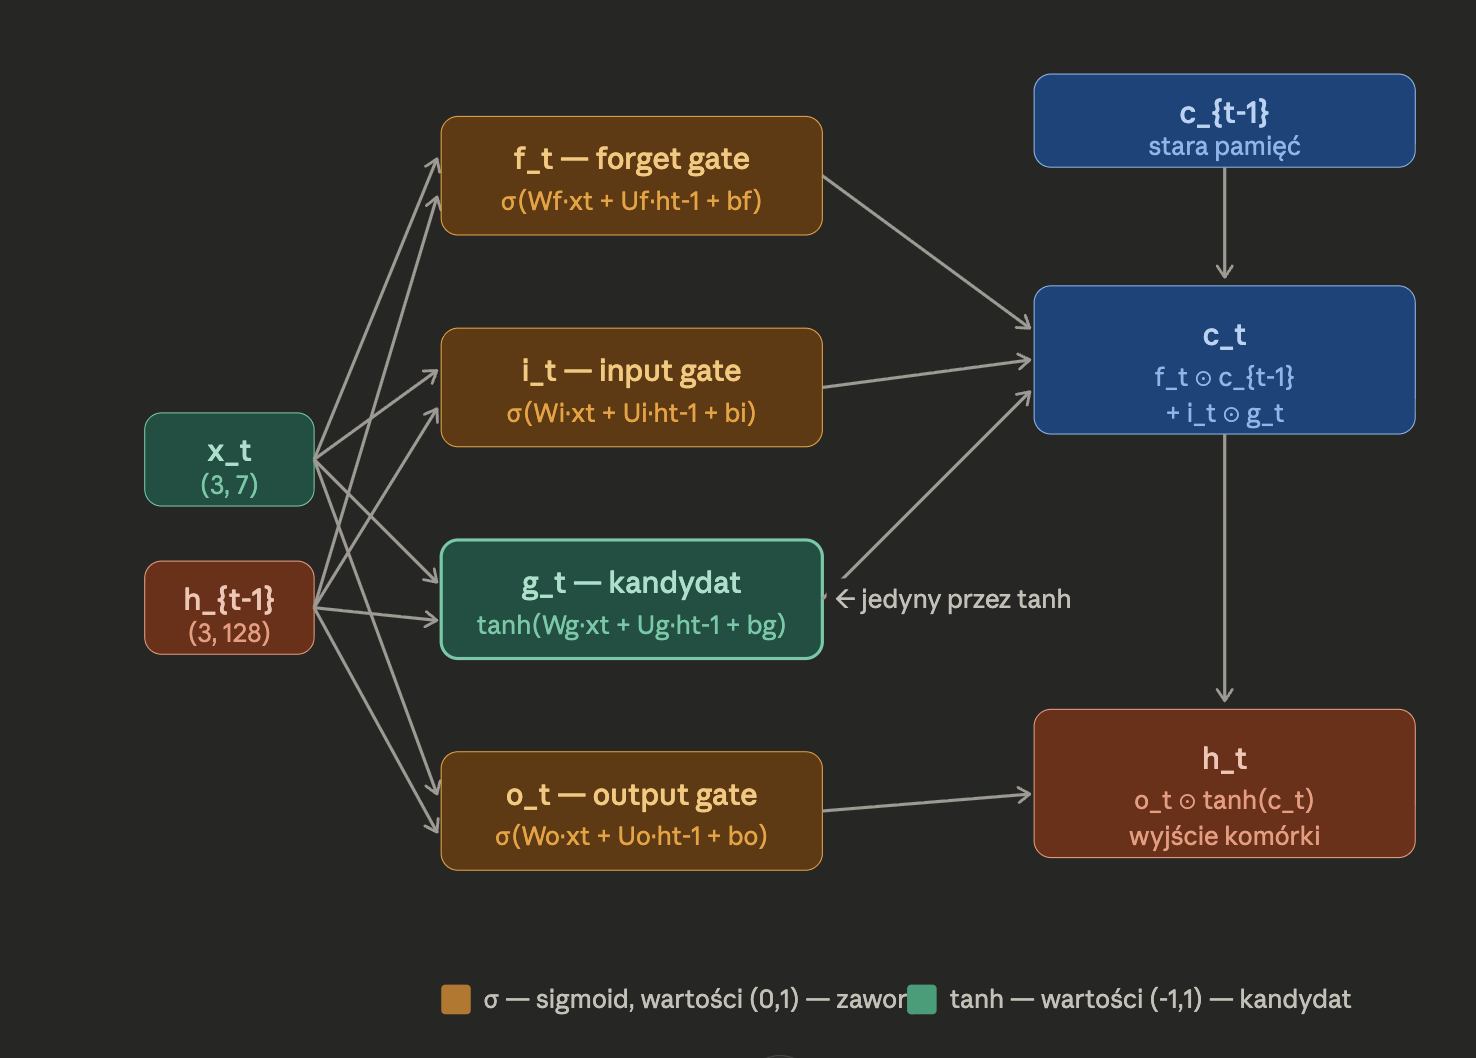

1 RNN timestep

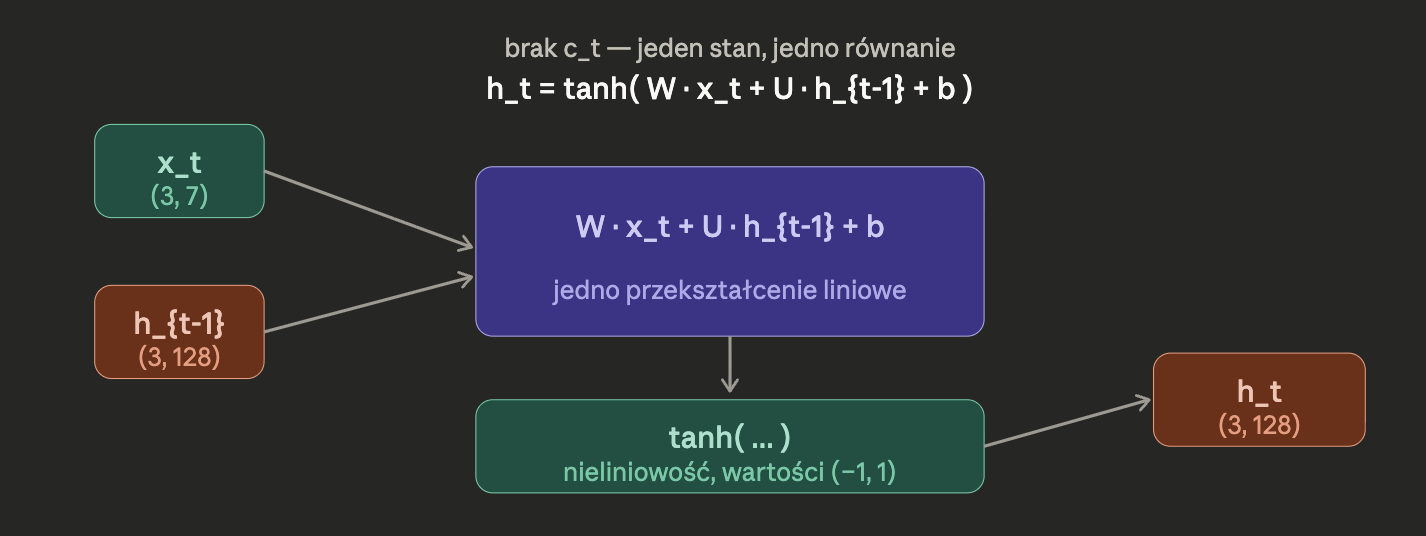

In [ ]:
seq_length = 5 # how many t's we input to hidden state from past in hidden2hidden
batch_size = 2

X = torch.randn(seq_length, batch_size, input_size)
X.shape

torch.Size([5, 2, 9])

In [ ]:
# create a hidden layer (typically initialized as zeros)
hidden = torch.zeros(num_layers, batch_size, hidden_size)

In [ ]:
# run some data through the model and show the output
y, h = rnn(X, hidden)
print(f' Input shape: {list(X.shape)}')
print(f'Hidden shape: {list(h.shape)}')
print(f'Output shape: {list(y.shape)}')

 Input shape: [5, 2, 9]
Hidden shape: [1, 2, 16]
Output shape: [5, 2, 16]


In [ ]:
# Default hidden state is all zeros if nothing specified:
y, h1 = rnn(X, hidden)
print(h1), print('\n\n')

y, h2 = rnn(X)
print(h2), print('\n\n')

# they're the same (default = zero)
print(h1 == h2)

tensor([[[ 0.4567,  0.7519,  0.0866, -0.8473,  0.4726, -0.2934,  0.2309,
           0.3794, -0.4670, -0.0304,  0.3670, -0.6398, -0.5941,  0.5613,
          -0.5907,  0.8208],
         [-0.4535, -0.1018,  0.1835, -0.0745, -0.4746, -0.7355, -0.3044,
          -0.5144, -0.5561, -0.0607, -0.2728,  0.4414,  0.1790,  0.5944,
           0.0943,  0.7228]]], grad_fn=<StackBackward0>)



tensor([[[ 0.4567,  0.7519,  0.0866, -0.8473,  0.4726, -0.2934,  0.2309,
           0.3794, -0.4670, -0.0304,  0.3670, -0.6398, -0.5941,  0.5613,
          -0.5907,  0.8208],
         [-0.4535, -0.1018,  0.1835, -0.0745, -0.4746, -0.7355, -0.3044,
          -0.5144, -0.5561, -0.0607, -0.2728,  0.4414,  0.1790,  0.5944,
           0.0943,  0.7228]]], grad_fn=<StackBackward0>)



tensor([[[True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True]]])


In [ ]:
# check out the learned parameters and their sizes

for p in rnn.named_parameters():
  if 'weight' in p[0]:
    print(f'{p[0]} has size {list(p[1].shape)}')

weight_ih_l0 has size [16, 9]
weight_hh_l0 has size [16, 16]


Each hidden state takes 2 inputs, for example $h_t$ takes:

1. $x_t$
2. $h_{t-1}$

So, hidden state $h_t$ actually never takes past $x$ as input. Whole past is represented by previous hidden state $h_{t-1}$. This resembles Markov's rule which states that only last state matters, since it represents the past perfectly, i.e. there is no need to see at whole past - last state has already taken what's most significant into account. In RNN, however we have $h_t$ hidden state instead of $s_t$ state but the idea is the same.

# DL Model Class

In [ ]:
class RNNnet(nn.Module):
  def __init__(self, input_size, num_hidden, num_layers):
    super().__init__()

    # store parameters
    self.input_size = input_size
    self.num_hidden = num_hidden
    self.num_layers = num_layers

    # RNN layer
    self.rnn = nn.RNN(input_size, num_hidden, num_layers)

    # linear layer for output
    self.out = nn.Linear(num_hidden, 1)

  def forward(self, x):

    print(f'Input: {list(x.shape)}')

    # initialize hidden state for first input
    hidden = torch.zeros(self.num_layers, batch_size, self.num_hidden)
    print(f'Hidden: {list(hidden.shape)}')

    # run through the RNN layer
    y, hidden = self.rnn(x, hidden)
    print(f'RNN-out: {list(y.shape)}')
    print(f'RNN-hidden: {list(hidden.shape)}')

    # pass the RNN output through the linear output layer
    o = self.out(y)
    print(f'Output: {list(o.shape)}')

    return o, hidden

In [ ]:
net = RNNnet(input_size, hidden_size, num_layers)
print(net), print(' ')

# and check out all learnable parameters
for p in net.named_parameters():
  print(f'{p[0]} has size {list(p[1].shape)}')

RNNnet(
  (rnn): RNN(9, 16)
  (out): Linear(in_features=16, out_features=1, bias=True)
)
 
rnn.weight_ih_l0 has size [16, 9]
rnn.weight_hh_l0 has size [16, 16]
rnn.bias_ih_l0 has size [16]
rnn.bias_hh_l0 has size [16]
out.weight has size [1, 16]
out.bias has size [1]


In [ ]:
# test the model with some data
X = torch.rand(seq_length, batch_size, input_size)
y = torch.rand(seq_length, batch_size, 1)
y_hat, h = net(X)

# try a loss function
loss_fn = nn.MSELoss()
loss_fn(y_hat, y)

Input: [5, 2, 9]
Hidden: [1, 2, 16]
RNN-out: [5, 2, 16]
RNN-hidden: [1, 2, 16]
Output: [5, 2, 1]


tensor(0.1540, grad_fn=<MseLossBackward0>)

# Predicting Alternating Sequences

## Imports

In [ ]:
import torch
import torch.nn as nn
import numpy as np

import sys

import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

/tmp/ipykernel_614/2870380934.py:9: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


## Temporal sequence data

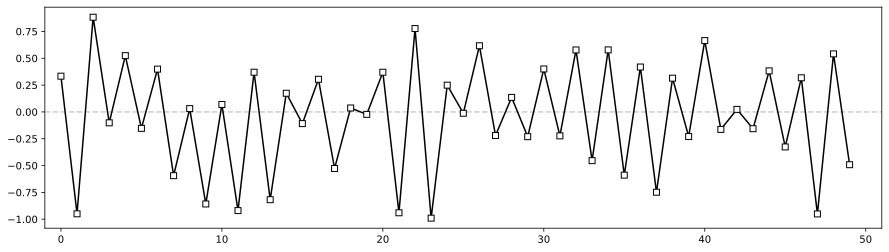

In [ ]:
N = 50

data = torch.zeros(N)

for i in range(N):
  data[i] = torch.rand(1) * (-1)**i

plt.figure(figsize = (15,4))
plt.plot([-1, N+1], [0,0], '--', color = [.8,.8,.8])
plt.plot(data, 'ks-', markerfacecolor = 'w')
plt.xlim([-1,N+1])
plt.show()

## Create a class for the DL model

In [ ]:
class RNNnet(nn.Module):
  def __init__(self, input_size, hidden_size, layers_num):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.layers_num = layers_num

    self.rnn = nn.RNN(input_size, hidden_size, layers_num)

    self.out = nn.Linear(hidden_size, 1)

  def forward(self, x):

    y, hidden = self.rnn(x)
    o = self.out(y)

    return o, hidden

### Params

In [ ]:
input_size = 1
hidden_size = 4
layers_num = 1

seq_len = int(N/25)
batch_size = 5

### Model Init

In [ ]:
rnn = RNNnet(input_size, hidden_size, layers_num)
rnn

RNNnet(
  (rnn): RNN(1, 4)
  (out): Linear(in_features=4, out_features=1, bias=True)
)

### One Spin Data

In [ ]:
# we take data chunk for 1 spin
X = data[:int(seq_len * batch_size)].view(batch_size, seq_len)
y = data[int(seq_len * batch_size):2*int(seq_len * batch_size)].reshape(batch_size, seq_len)

y_hat, hidden = rnn(X.T.unsqueeze(2))
y_hat, hidden

(tensor([[[0.1552],
          [0.1830],
          [0.1655],
          [0.1588],
          [0.1374]],
 
         [[0.0633],
          [0.1182],
          [0.1152],
          [0.0871],
          [0.0688]]], grad_fn=<ViewBackward0>),
 tensor([[[-0.2157, -0.1863, -0.2421,  0.3112],
          [-0.2527,  0.0353, -0.5217,  0.3214],
          [-0.2442,  0.0477, -0.5004,  0.3232],
          [-0.2281, -0.0812, -0.3641,  0.3167],
          [-0.2109, -0.1308, -0.2663,  0.3163]]], grad_fn=<StackBackward0>))

### Loss

In [ ]:
loss_fn = nn.MSELoss()
print(f'One spin loss: {loss_fn(y, y_hat).item():.3f}')

One spin loss: 0.260


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 5, 1])) that is different to the input size (torch.Size([5, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


### Train

In [ ]:
# number of training epochs
epochs = 30

# create a new instance of the model (and optimizer)
rnn = RNNnet(input_size, hidden_size, layers_num)
optimizer = torch.optim.SGD(net.parameters(), lr = 0.001)

# initialize losses
losses = np.zeros(epochs)
sign_accuracy = np.zeros(epochs)

# loop over epochs
for epoch in range(epochs):
  # loop over data segments
  segment_losses = []
  segment_acc    = []
  hidden_state   = torch.zeros(num_layers, batch_size, hidden_size) # reset the hidden state

  for time_i in range(N - 2 * seq_len * batch_size):

    # we take data chunk for 1 spin
    X = data[time_i:time_i+int(seq_len * batch_size)].view(batch_size, seq_len)
    y = data[time_i+int(seq_len * batch_size):time_i + 2*int(seq_len * batch_size)].reshape(batch_size, seq_len)

    y_hat, hidden = rnn(X.T.unsqueeze(2))

    y_hat_single =

torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([

# Sin Wave Extrapolation

In [ ]:
import torch
import torch.nn as nn
import numpy as np

import sys

import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

/tmp/ipykernel_4050/2870380934.py:9: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


## Data

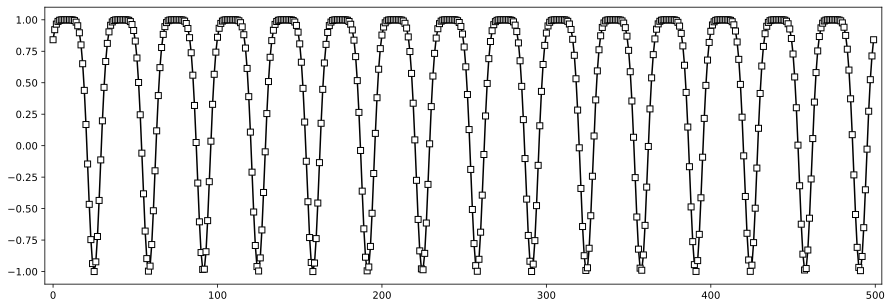

In [243]:
N = 500

time = torch.linspace(0, 30 * torch.pi, N)
data = torch.sin(time + torch.cos(time))

plt.figure(figsize = (15,5))
plt.plot(data, 'ks-', markerfacecolor = 'w')
plt.xlim([-5,N+4])
plt.show()

## Model

In [ ]:
class RNNnet(nn.Module):
  def __init__(self, input_size, hidden_size, layers_num):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.layers_num = layers_num

    self.rnn = nn.RNN(self.input_size,
                      self.hidden_size,
                      self.layers_num,
                      batch_first = True)

    self.out = nn.Linear(hidden_size, 1)

  def forward(self, x, h):

    y, hidden = self.rnn(x, h)

    y = self.out(y)

    return y, hidden.detach()

## Parameters

In [ ]:
input_size  = 1
hidden_size = 9
layers_num  = 1

seq_len    = 30
batch_size = 1

rnn = RNNnet(input_size, hidden_size, layers_num)

X = torch.randn(batch_size, seq_len, input_size)

y, hidden = rnn(X, None)

print('X shape:     ', X.shape)
print('y shape:     ', y.shape)
print('hidden shape:', hidden.shape)

X shape:      torch.Size([1, 30, 1])
y shape:      torch.Size([1, 30, 1])
hidden shape: torch.Size([1, 1, 9])


## Plot

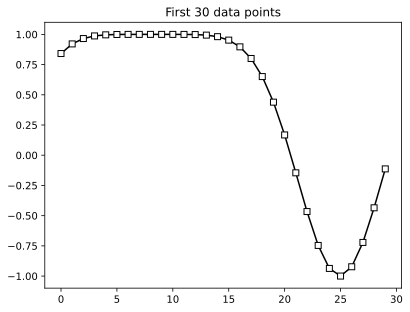

In [ ]:
plt.plot(data[:seq_len], 'ks-', markerfacecolor = 'w')
plt.title(f'First {seq_len} data points')
plt.show()

## Test Model

In [ ]:
some_data = data[:seq_len].view(batch_size, seq_len, input_size)
print('some_data shape:', some_data.shape)

y, h = rnn(some_data, None)

loss_fn = nn.MSELoss()
loss    = loss_fn(y[0][-1], data[seq_len].view(1,1))
print('Final Value:    ', round(loss.item(),4))

some_data shape: torch.Size([1, 30, 1])
Final Value:     0.0112


## Train Model

In [ ]:
epochs = 30

rnn = RNNnet(input_size, hidden_size, layers_num)
optimizer = torch.optim.SGD(rnn.parameters(), lr = 1e-3)

losses = torch.zeros(epochs)
sgn_accs = torch.zeros(epochs)

for epoch in range(epochs):

  # store eval
  seg_losses = torch.zeros(N-seq_len)
  seg_sgn_accs = torch.zeros(N-seq_len)

  # hidden init
  hidden_state = None

  # time loop
  for t in range(N-seq_len):

    # data
    X = data[t:t+seq_len].view(batch_size, seq_len, input_size)
    y = data[t+seq_len]

    # train
    y_hat, hidden_state = rnn(X, hidden_state)
    hidden_state = hidden_state.detach()

    # single pred
    final_pred = y_hat[0][-1]

    # loss
    loss = loss_fn(final_pred, y)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # store
    seg_losses[t] = loss
    seg_sgn_accs[t] = torch.sign(final_pred) == torch.sign(y)

  # store
  losses[epoch] = torch.mean(seg_losses)
  sgn_accs[epoch] = torch.mean(seg_sgn_accs.float())

  # msg
  msg = f'Epoch {epoch+1}/{epochs}'
  sys.stdout.write('\r' + msg)

Epoch 30/30

## Plot

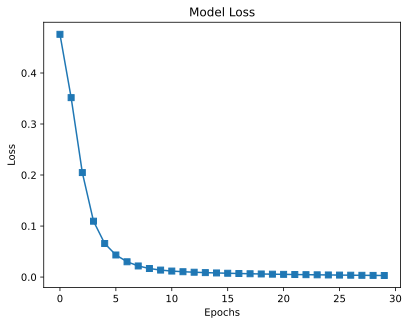

In [ ]:
plt.plot(losses.detach(), 's-')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

## Test the Net

In [ ]:
hidden_layers = torch.zeros((N, hidden_size))
y_hats = torch.zeros(N)

hh = None

for t in range(N-seq_len):
  X = data[t:t+seq_len].view(batch_size, seq_len, input_size)
  y = data[t+seq_len]

  yy, hh = rnn(X, hh)

  y_hat = yy[0][-1]
  y_hats[t+seq_len] = y_hat
  hidden_layers[t,:] = hh.detach()

## Plot

### General

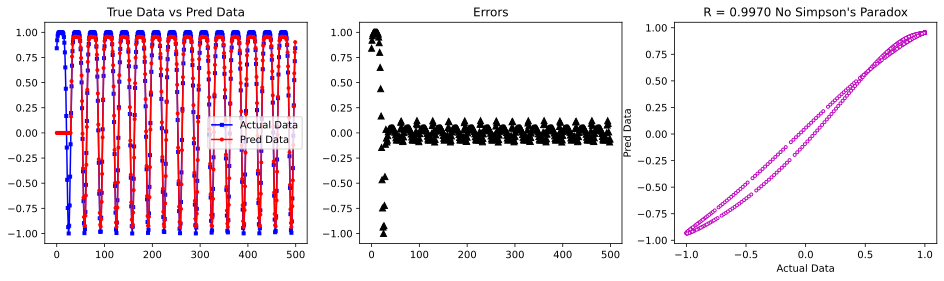

In [ ]:
fig, axs = plt.subplots(1,3,figsize = (16,4))

axs[0].plot(data, 'bs-', markersize = 3, label = 'Actual Data')
axs[0].plot(y_hats.detach(), 'ro-', markersize = 3, label = 'Pred Data')
axs[0].set_title('True Data vs Pred Data')
axs[0].set_ylim([-1.1,1.1])
axs[0].legend()

axs[1].plot(data - y_hats.detach(), 'k^')
axs[1].set_title('Errors')
axs[1].set_ylim([-1.1,1.1])

axs[2].plot(data[seq_len:], y_hats[seq_len:].detach(), 'mo', markerfacecolor = 'w', markersize = 3)
axs[2].set_xlabel('Actual Data')
axs[2].set_ylabel('Pred Data')
r = np.corrcoef(data[seq_len:], y_hats[seq_len:].detach())
axs[2].set_title(f'R = {r[0,1]:.4f} No Simpson\'s Paradox')

plt.show()

### Hidden States

Text(0.5, 1.0, 'Each line is a different hidden')

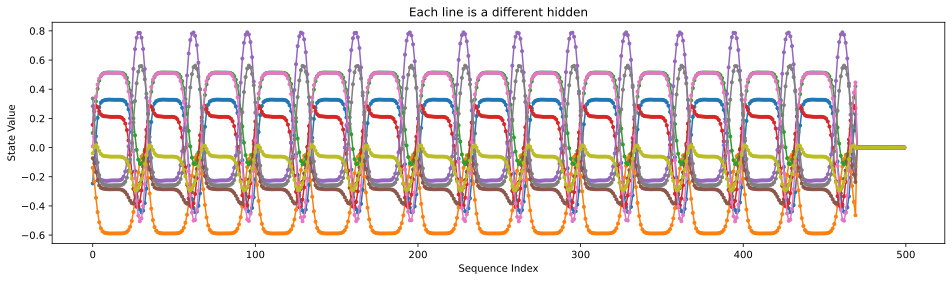

In [ ]:
plt.figure(figsize=(16,4))

plt.plot(hidden_layers, 'o-', markersize = 3)
plt.xlabel('Sequence Index')
plt.ylabel('State Value')
plt.title('Each line is a different hidden')

### Weights

 plot the weights for the input->hidden layers

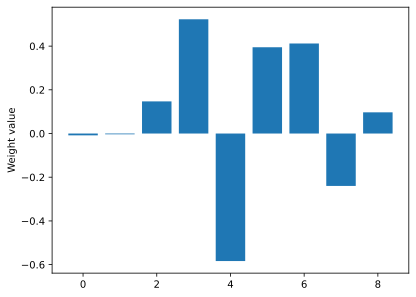

In [ ]:
plt.bar(range(hidden_size), rnn.rnn.weight_ih_l0[:,0].detach())
plt.ylabel('Weight value')
plt.show()

## Test Data

In [ ]:
def run_experiment(data):
  # loop over time and predict each subsequent value
  y_hats = torch.zeros(N)
  hh = None
  h = torch.zeros((N, hidden_size))

  for t in range(N-seq_len):

    X = data[t:t+seq_len].view(batch_size, seq_len, input_size)

    yy, hh = rnn(X, hh)
    hh = hh.detach()
    y_hats[t + seq_len] = yy[0][-1].item()
    # h[t + seq_len,:] = hh[-1, 0, :].detach()
    h[t + seq_len,:] = hh.detach()

  fig, axs = plt.subplots(1,3,figsize = (16,4))

  axs[0].plot(data, 'bs-', markersize = 3, label = 'Actual Data')
  axs[0].plot(y_hats.detach(), 'ro-', markersize = 3, label = 'Pred Data')
  axs[0].set_title('True Data vs Pred Data')
  axs[0].set_ylim([-1.1,1.1])
  axs[0].legend()

  axs[1].plot(data - y_hats.detach(), 'k^')
  axs[1].set_title('Errors')
  axs[1].set_ylim([-1.1,1.1])

  axs[2].plot(data[seq_len:], y_hats[seq_len:].detach(), 'mo', markerfacecolor = 'w', markersize = 3)
  axs[2].set_xlabel('Actual Data')
  axs[2].set_ylabel('Pred Data')
  r = np.corrcoef(data[seq_len:], y_hats[seq_len:].detach())
  axs[2].set_title(f'R = {r[0,1]:.4f} No Simpson\'s Paradox')

  plt.show()

### $\text{sin(time + cos(time))},\; t\in(0,30\pi)$

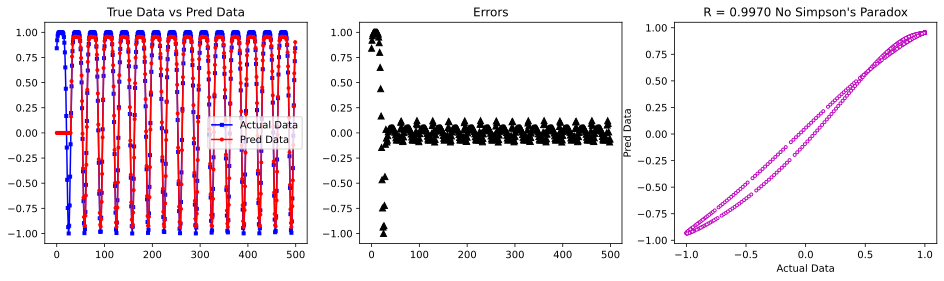

In [ ]:
# Create new data (orange case: different frequency)
time = torch.linspace(0, 30*np.pi, N)
new_data = torch.sin(time + torch.cos(time))

run_experiment(new_data)

### $\text{sin(time + cos(time))},\; t\in(0,10\pi)$

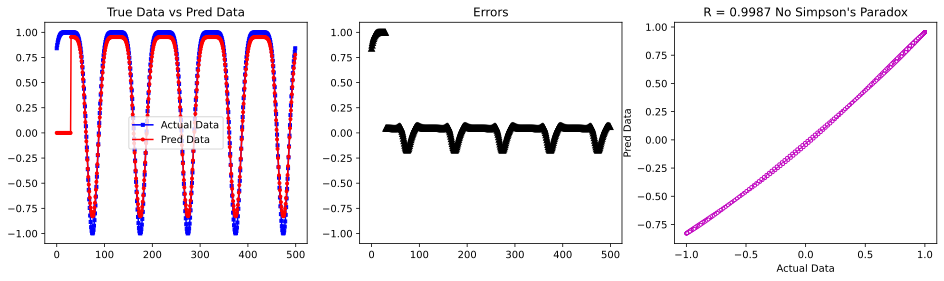

In [ ]:
time = torch.linspace(0,10*np.pi,N)
new_data = torch.sin(time + torch.cos(time))

run_experiment(new_data)

### $\text{sin(time + sin(time))},\; t\in(0,30\pi)$

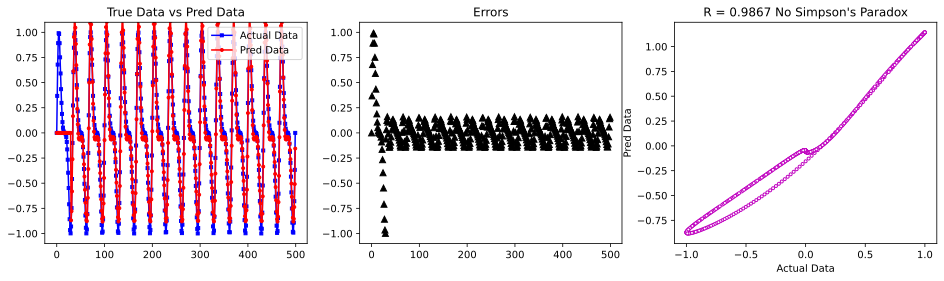

In [242]:
time = torch.linspace(0,30*np.pi,N)
new_data = torch.sin(time + torch.sin(time))

run_experiment(new_data)

## Longer-Term Extrapolation

### Prepare

Same data and model as original

In [244]:
############
### Data ###
############

N = 500

time = torch.linspace(0, 30 * torch.pi, N)
data = torch.sin(time + torch.cos(time))

#############
### Model ###
#############

class RNNnet(nn.Module):
  def __init__(self, input_size, hidden_size, layers_num):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.layers_num = layers_num

    self.rnn = nn.RNN(self.input_size,
                      self.hidden_size,
                      self.layers_num,
                      batch_first = True)

    self.out = nn.Linear(hidden_size, 1)

  def forward(self, x, h):

    y, hidden = self.rnn(x, h)

    y = self.out(y)

    return y, hidden.detach()

##################
### MODEL INIT ###
##################

input_size  = 1
hidden_size = 9
layers_num  = 1

seq_len    = 30
batch_size = 1

rnn = RNNnet(input_size, hidden_size, layers_num)

X = torch.randn(batch_size, seq_len, input_size)

y, hidden = rnn(X, None)

#############
### TRAIN ###
#############

epochs = 30

rnn = RNNnet(input_size, hidden_size, layers_num)
optimizer = torch.optim.SGD(rnn.parameters(), lr = 1e-3)

losses = torch.zeros(epochs)
sgn_accs = torch.zeros(epochs)

for epoch in range(epochs):

  # store eval
  seg_losses = torch.zeros(N-seq_len)
  seg_sgn_accs = torch.zeros(N-seq_len)

  # hidden init
  hidden_state = None

  # time loop
  for t in range(N-seq_len):

    # data
    X = data[t:t+seq_len].view(batch_size, seq_len, input_size)
    y = data[t+seq_len]

    # train
    y_hat, hidden_state = rnn(X, hidden_state)
    hidden_state = hidden_state.detach()

    # single pred
    final_pred = y_hat[0][-1]

    # loss
    loss = loss_fn(final_pred, y)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # store
    seg_losses[t] = loss
    seg_sgn_accs[t] = torch.sign(final_pred) == torch.sign(y)

  # store
  losses[epoch] = torch.mean(seg_losses)
  sgn_accs[epoch] = torch.mean(seg_sgn_accs.float())

  # msg
  msg = f'Epoch {epoch+1}/{epochs}'
  sys.stdout.write('\r' + msg)

Epoch 30/30

### Extrapolation

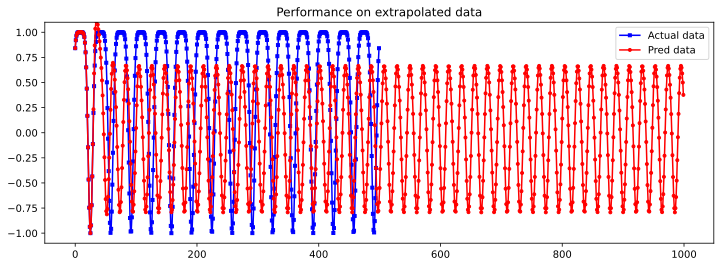

In [245]:
y_hat = torch.zeros(2*N)
y_hat[:N] = data
hidden = None

for t in range(2*N-seq_len):

  X = y_hat[t:t+seq_len].view(batch_size, seq_len, input_size)

  yy, hidden = rnn(X, hidden)
  # hidden = hidden.detach()
  y_hat[t+seq_len] = yy[0,-1,0]

y_hat = y_hat.detach()

fig = plt.figure(figsize=(12,4))
plt.plot(data,  'bs-', label = 'Actual data',markersize =3)
plt.plot(y_hat, 'ro-', label = 'Pred data',  markersize = 3)
plt.ylim([-1.1,1.1])
plt.legend()
plt.title('Performance on extrapolated data')
plt.show()

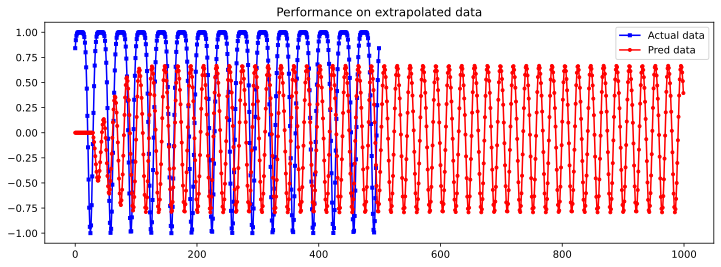

In [259]:
y_hat = torch.zeros(N*2)

for t in range(2*N - seq_len):
  X = y_hat[t:t+seq_len].view(batch_size, seq_len, input_size)

  yy, hh = rnn(X, hidden)
  hh = hh.detach()

  y_hat[t+seq_len] = yy[0,-1,0]

y_hat = y_hat.detach()

fig = plt.figure(figsize=(12,4))
plt.plot(data,  'bs-', label = 'Actual data',markersize =3)
plt.plot(y_hat, 'ro-', label = 'Pred data',  markersize = 3)
plt.ylim([-1.1,1.1])
plt.legend()
plt.title('Performance on extrapolated data')
plt.show()